# Data & Packages

In [1]:
# Main Packages 
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy

# Clustering 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score, adjusted_rand_score, mutual_info_score

# Parallel processing 
from joblib import Parallel, delayed

In [2]:
# Load data
df = pl.scan_csv("/home/lanl/data/cyber1/auth.txt.gz",has_header=False,separator=",",
                 new_columns= ['time','src_user','dest_user','src_comp','dest_comp',
                               'auth_type','logon_type','auth_orientation','outcome'])

In [3]:
# Keep only human users
df = df.filter(pl.col("src_user").str.starts_with("U"))

In [4]:
# Time conversions
seconds_in_day = 60 * 60 * 24
eight_weeks_seconds = 8 * 7 * seconds_in_day

In [5]:
# Keep the first 8 weeks of data
df = df.filter(pl.col("time") <= eight_weeks_seconds)

In [6]:
# Chosen features
feature_cols = [
    'log_n_events',
    'log_n_distinct_src',
    'log_n_distinct_dest',
    'failure_ratio',
    'c_bar',
    's_bar',
    ]

# Functions

In [7]:
# Build the features dataframe
def build_features(df,agg_hour_level):

    agg_seconds = agg_hour_level * 60 * 60 

    return (
        df.with_columns(
            bucket = pl.col('time') // agg_seconds,
            theta = ((pl.col('time') % seconds_in_day)/seconds_in_day) * 2 * np.pi,
            is_failure = (pl.col('outcome') == 'Fail').cast(pl.Int8),
        )
        .group_by(['src_user','bucket'])
        .agg(
            n_events = pl.len(),
            failure_ratio = pl.col('is_failure').mean(),
            n_distinct_src = pl.col('src_comp').n_unique(),
            n_distinct_dest = pl.col('dest_comp').n_unique(),
            c_bar = pl.col('theta').cos().mean(),
            s_bar = pl.col('theta').sin().mean(),
        )
        .with_columns(
            log_n_events = pl.col('n_events').log(),
            log_n_distinct_src = pl.col('n_distinct_src').log(),
            log_n_distinct_dest = pl.col('n_distinct_dest').log(),
        ).collect()
        )

In [8]:
# Process features for clustering
def cluster_preprocess(features_df, X_scaled, week):

    lb = (week - 1) * buckets_per_week
    ub = lb + buckets_per_week - 1

    in_bin = features_df['bucket'].is_between(lb,ub).to_numpy()

    features_week = features_df.filter(in_bin)
    X_scaled_week = X_scaled[in_bin]

    return features_week, X_scaled_week 

# 1 Hour

In [9]:
# Time aggregation
agg_hour_level = 1

# Number of buckets in a week of data
buckets_per_week = (7 * 24) // agg_hour_level

In [10]:
# Build the features dataframe
features_df = build_features(df, agg_hour_level)

In [11]:
# Standardise features
X = features_df.select(feature_cols).to_numpy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
# Cluster for each week 
n_weeks = 8
k = 2
weekly_results = {}

for week in range(1, n_weeks + 1):

    features_week, X_scaled_week = cluster_preprocess(features_df,X_scaled, week)

    km = KMeans(n_clusters=k, random_state=123, n_init=10)
    labels = km.fit_predict(X_scaled_week)

    features_week = (features_week.with_columns(pl.Series('cluster',labels)).select(['src_user','bucket','cluster']))

    weekly_results[week] = features_week

In [ ]:
# ARI (clustering stability) scores
ARI_scores = {}

for week in range(1, n_weeks):

    w_curr = weekly_results[week].with_columns(
        relative_bucket = pl.col('bucket') % buckets_per_week
    )

    w_next = weekly_results[week + 1].with_columns(
        relative_bucket = pl.col('bucket') % buckets_per_week
    )

    overlap = w_curr.join(w_next,on = ['src_user','relative_bucket'],how = 'inner',suffix = '_next')


    labels_curr = overlap['cluster'].to_numpy()
    labels_next =  overlap['cluster_next'].to_numpy()
    
    ARI = adjusted_rand_score(labels_curr, labels_next)

    ARI_scores[(week, week + 1)] = ARI

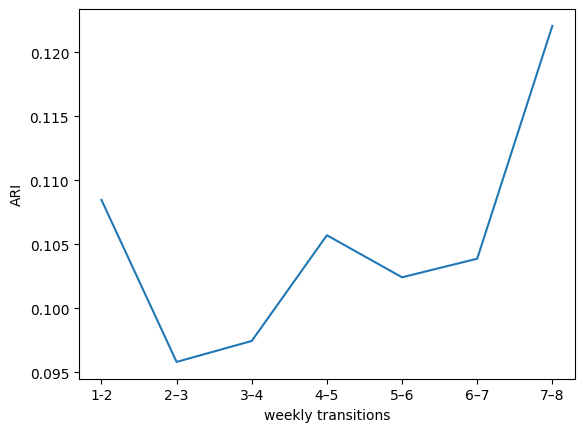

In [ ]:
plt.plot(list(ARI_scores.values()))
plt.ylabel('ARI')
plt.xlabel('weekly transitions')
labels = ['1-2', '2–3', '3–4', '4–5', '5–6', '6–7', '7–8']
plt.xticks(ticks=range(len(labels)), labels=labels)

# 3 Hour

In [24]:
# Time aggregation
agg_hour_level = 3

# Number of buckets in a week of data
buckets_per_week = (7 * 24) // agg_hour_level

In [25]:
# Build the features dataframe
features_df = build_features(df, agg_hour_level)

In [26]:
# Standardise features
X = features_df.select(feature_cols).to_numpy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [27]:
# Cluster for each week 
n_weeks = 8
k = 2
weekly_results = {}

for week in range(1, n_weeks + 1):

    features_week, X_scaled_week = cluster_preprocess(features_df,X_scaled, week)

    km = KMeans(n_clusters=k, random_state=123, n_init=10)
    labels = km.fit_predict(X_scaled_week)

    features_week = (features_week.with_columns(pl.Series('cluster',labels)).select(['src_user','bucket','cluster']))

    weekly_results[week] = features_week

In [28]:
# ARI (clustering stability) scores
ARI_scores = {}

for week in range(1, n_weeks):

    w_curr = weekly_results[week].with_columns(
        relative_bucket = pl.col('bucket') % buckets_per_week
    )

    w_next = weekly_results[week + 1].with_columns(
        relative_bucket = pl.col('bucket') % buckets_per_week
    )

    overlap = w_curr.join(w_next,on = ['src_user','relative_bucket'],how = 'inner',suffix = '_next')


    labels_curr = overlap['cluster'].to_numpy()
    labels_next =  overlap['cluster_next'].to_numpy()
    
    ARI = adjusted_rand_score(labels_curr, labels_next)

    ARI_scores[(week, week + 1)] = ARI

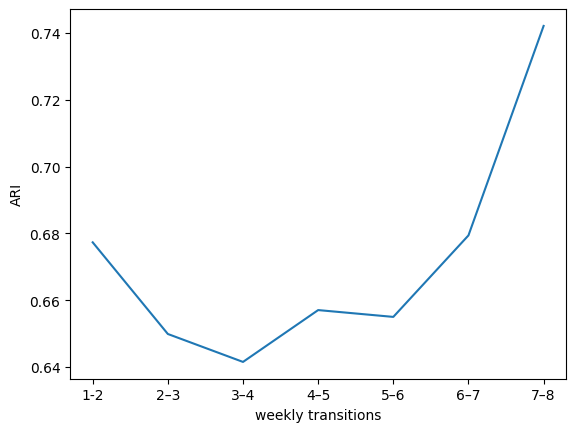

In [30]:
plt.plot(list(ARI_scores.values()))
plt.ylabel('ARI')
plt.xlabel('weekly transitions')
labels = ['1-2', '2–3', '3–4', '4–5', '5–6', '6–7', '7–8']
plt.xticks(ticks=range(len(labels)), labels=labels);

# 6 Hour

In [31]:
# Time aggregation
agg_hour_level = 6

# Number of buckets in a week of data
buckets_per_week = (7 * 24) // agg_hour_level

In [32]:
# Build the features dataframe
features_df = build_features(df, agg_hour_level)

In [33]:
# Standardise features
X = features_df.select(feature_cols).to_numpy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [34]:
# Cluster for each week 
n_weeks = 8
k = 2
weekly_results = {}

for week in range(1, n_weeks + 1):

    features_week, X_scaled_week = cluster_preprocess(features_df,X_scaled, week)

    km = KMeans(n_clusters=k, random_state=123, n_init=10)
    labels = km.fit_predict(X_scaled_week)

    features_week = (features_week.with_columns(pl.Series('cluster',labels)).select(['src_user','bucket','cluster']))

    weekly_results[week] = features_week

In [35]:
# ARI (clustering stability) scores
ARI_scores = {}

for week in range(1, n_weeks):

    w_curr = weekly_results[week].with_columns(
        relative_bucket = pl.col('bucket') % buckets_per_week
    )

    w_next = weekly_results[week + 1].with_columns(
        relative_bucket = pl.col('bucket') % buckets_per_week
    )

    overlap = w_curr.join(w_next,on = ['src_user','relative_bucket'],how = 'inner',suffix = '_next')


    labels_curr = overlap['cluster'].to_numpy()
    labels_next =  overlap['cluster_next'].to_numpy()
    
    ARI = adjusted_rand_score(labels_curr, labels_next)

    ARI_scores[(week, week + 1)] = ARI

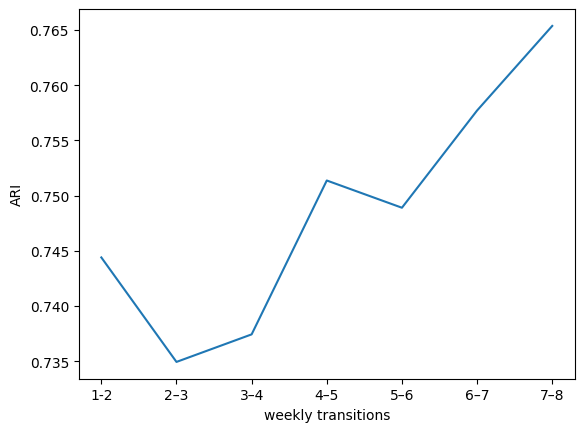

In [36]:
plt.plot(list(ARI_scores.values()))
plt.ylabel('ARI')
plt.xlabel('weekly transitions')
labels = ['1-2', '2–3', '3–4', '4–5', '5–6', '6–7', '7–8']
plt.xticks(ticks=range(len(labels)), labels=labels);

# 30 Mins

In [37]:
# Time aggregation
agg_hour_level = 0.5

# Number of buckets in a week of data
buckets_per_week = (7 * 24) // agg_hour_level

In [38]:
# Build the features dataframe
features_df = build_features(df, agg_hour_level)

In [39]:
# Standardise features
X = features_df.select(feature_cols).to_numpy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [40]:
# Cluster for each week 
n_weeks = 8
k = 2
weekly_results = {}

for week in range(1, n_weeks + 1):

    features_week, X_scaled_week = cluster_preprocess(features_df,X_scaled, week)

    km = KMeans(n_clusters=k, random_state=123, n_init=10)
    labels = km.fit_predict(X_scaled_week)

    features_week = (features_week.with_columns(pl.Series('cluster',labels)).select(['src_user','bucket','cluster']))

    weekly_results[week] = features_week

In [41]:
# ARI (clustering stability) scores
ARI_scores = {}

for week in range(1, n_weeks):

    w_curr = weekly_results[week].with_columns(
        relative_bucket = pl.col('bucket') % buckets_per_week
    )

    w_next = weekly_results[week + 1].with_columns(
        relative_bucket = pl.col('bucket') % buckets_per_week
    )

    overlap = w_curr.join(w_next,on = ['src_user','relative_bucket'],how = 'inner',suffix = '_next')


    labels_curr = overlap['cluster'].to_numpy()
    labels_next =  overlap['cluster_next'].to_numpy()
    
    ARI = adjusted_rand_score(labels_curr, labels_next)

    ARI_scores[(week, week + 1)] = ARI

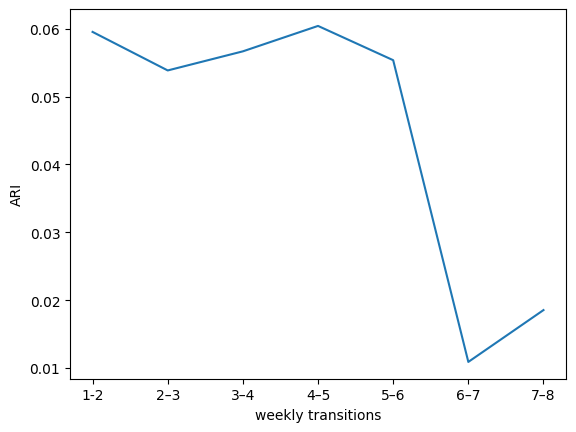

In [42]:
plt.plot(list(ARI_scores.values()))
plt.ylabel('ARI')
plt.xlabel('weekly transitions')
labels = ['1-2', '2–3', '3–4', '4–5', '5–6', '6–7', '7–8']
plt.xticks(ticks=range(len(labels)), labels=labels);

# 10 Mins

In [43]:
# Time aggregation
agg_hour_level = 1/6

# Number of buckets in a week of data
buckets_per_week = (7 * 24) // agg_hour_level

In [44]:
# Build the features dataframe
features_df = build_features(df, agg_hour_level)

In [45]:
# Standardise features
X = features_df.select(feature_cols).to_numpy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [46]:
# Cluster for each week 
n_weeks = 8
k = 2
weekly_results = {}

for week in range(1, n_weeks + 1):

    features_week, X_scaled_week = cluster_preprocess(features_df,X_scaled, week)

    km = KMeans(n_clusters=k, random_state=123, n_init=10)
    labels = km.fit_predict(X_scaled_week)

    features_week = (features_week.with_columns(pl.Series('cluster',labels)).select(['src_user','bucket','cluster']))

    weekly_results[week] = features_week

In [47]:
# ARI (clustering stability) scores
ARI_scores = {}

for week in range(1, n_weeks):

    w_curr = weekly_results[week].with_columns(
        relative_bucket = pl.col('bucket') % buckets_per_week
    )

    w_next = weekly_results[week + 1].with_columns(
        relative_bucket = pl.col('bucket') % buckets_per_week
    )

    overlap = w_curr.join(w_next,on = ['src_user','relative_bucket'],how = 'inner',suffix = '_next')


    labels_curr = overlap['cluster'].to_numpy()
    labels_next =  overlap['cluster_next'].to_numpy()
    
    ARI = adjusted_rand_score(labels_curr, labels_next)

    ARI_scores[(week, week + 1)] = ARI

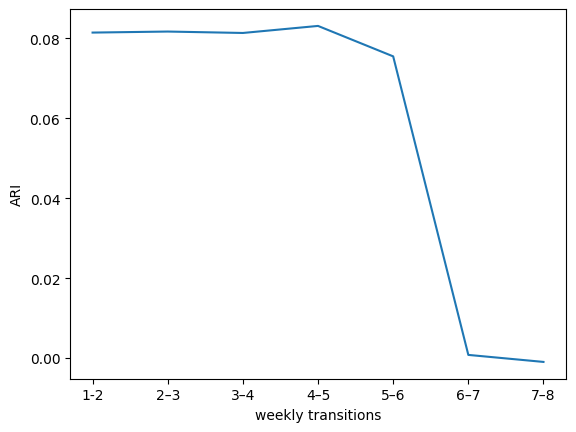

In [48]:
plt.plot(list(ARI_scores.values()))
plt.ylabel('ARI')
plt.xlabel('weekly transitions')
labels = ['1-2', '2–3', '3–4', '4–5', '5–6', '6–7', '7–8']
plt.xticks(ticks=range(len(labels)), labels=labels);

# 12 Hours

In [49]:
# Time aggregation
agg_hour_level = 12

# Number of buckets in a week of data
buckets_per_week = (7 * 24) // agg_hour_level

In [50]:
# Build the features dataframe
features_df = build_features(df, agg_hour_level)

In [51]:
# Standardise features
X = features_df.select(feature_cols).to_numpy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [52]:
# Cluster for each week 
n_weeks = 8
k = 2
weekly_results = {}

for week in range(1, n_weeks + 1):

    features_week, X_scaled_week = cluster_preprocess(features_df,X_scaled, week)

    km = KMeans(n_clusters=k, random_state=123, n_init=10)
    labels = km.fit_predict(X_scaled_week)

    features_week = (features_week.with_columns(pl.Series('cluster',labels)).select(['src_user','bucket','cluster']))

    weekly_results[week] = features_week

In [53]:
# ARI (clustering stability) scores
ARI_scores = {}

for week in range(1, n_weeks):

    w_curr = weekly_results[week].with_columns(
        relative_bucket = pl.col('bucket') % buckets_per_week
    )

    w_next = weekly_results[week + 1].with_columns(
        relative_bucket = pl.col('bucket') % buckets_per_week
    )

    overlap = w_curr.join(w_next,on = ['src_user','relative_bucket'],how = 'inner',suffix = '_next')


    labels_curr = overlap['cluster'].to_numpy()
    labels_next =  overlap['cluster_next'].to_numpy()
    
    ARI = adjusted_rand_score(labels_curr, labels_next)

    ARI_scores[(week, week + 1)] = ARI

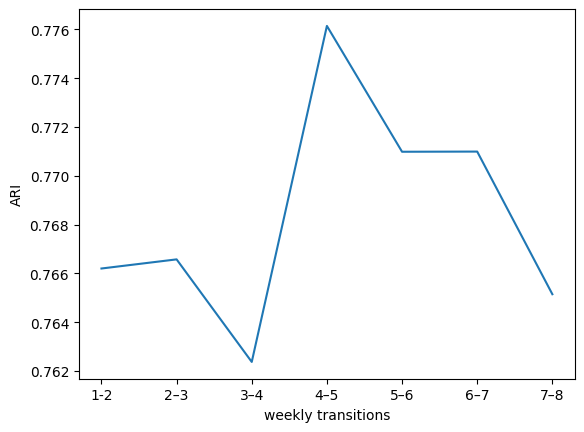

In [54]:
plt.plot(list(ARI_scores.values()))
plt.ylabel('ARI')
plt.xlabel('weekly transitions')
labels = ['1-2', '2–3', '3–4', '4–5', '5–6', '6–7', '7–8']
plt.xticks(ticks=range(len(labels)), labels=labels);

# 24 Hours

In [55]:
# Time aggregation
agg_hour_level = 24

# Number of buckets in a week of data
buckets_per_week = (7 * 24) // agg_hour_level

In [56]:
# Build the features dataframe
features_df = build_features(df, agg_hour_level)

In [57]:
# Standardise features
X = features_df.select(feature_cols).to_numpy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [58]:
# Cluster for each week 
n_weeks = 8
k = 2
weekly_results = {}

for week in range(1, n_weeks + 1):

    features_week, X_scaled_week = cluster_preprocess(features_df,X_scaled, week)

    km = KMeans(n_clusters=k, random_state=123, n_init=10)
    labels = km.fit_predict(X_scaled_week)

    features_week = (features_week.with_columns(pl.Series('cluster',labels)).select(['src_user','bucket','cluster']))

    weekly_results[week] = features_week

In [59]:
# ARI (clustering stability) scores
ARI_scores = {}

for week in range(1, n_weeks):

    w_curr = weekly_results[week].with_columns(
        relative_bucket = pl.col('bucket') % buckets_per_week
    )

    w_next = weekly_results[week + 1].with_columns(
        relative_bucket = pl.col('bucket') % buckets_per_week
    )

    overlap = w_curr.join(w_next,on = ['src_user','relative_bucket'],how = 'inner',suffix = '_next')


    labels_curr = overlap['cluster'].to_numpy()
    labels_next =  overlap['cluster_next'].to_numpy()
    
    ARI = adjusted_rand_score(labels_curr, labels_next)

    ARI_scores[(week, week + 1)] = ARI

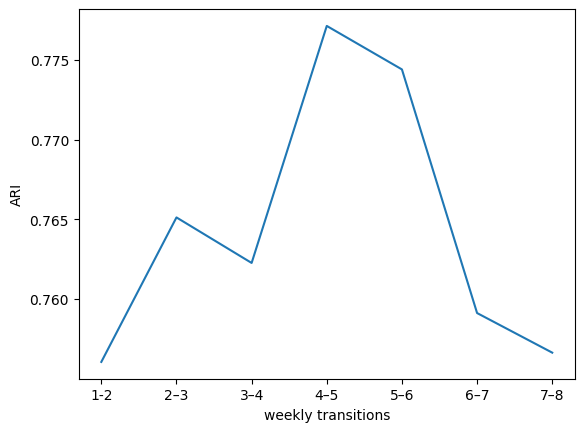

In [60]:
plt.plot(list(ARI_scores.values()))
plt.ylabel('ARI')
plt.xlabel('weekly transitions')
labels = ['1-2', '2–3', '3–4', '4–5', '5–6', '6–7', '7–8']
plt.xticks(ticks=range(len(labels)), labels=labels);

# 1 Min

In [61]:
# Time aggregation
agg_hour_level = 1/60

# Number of buckets in a week of data
buckets_per_week = (7 * 24) // agg_hour_level

In [62]:
# Build the features dataframe
features_df = build_features(df, agg_hour_level)

In [63]:
# Standardise features
X = features_df.select(feature_cols).to_numpy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [64]:
# Cluster for each week 
n_weeks = 8
k = 2
weekly_results = {}

for week in range(1, n_weeks + 1):

    features_week, X_scaled_week = cluster_preprocess(features_df,X_scaled, week)

    km = KMeans(n_clusters=k, random_state=123, n_init=10)
    labels = km.fit_predict(X_scaled_week)

    features_week = (features_week.with_columns(pl.Series('cluster',labels)).select(['src_user','bucket','cluster']))

    weekly_results[week] = features_week

In [65]:
# ARI (clustering stability) scores
ARI_scores = {}

for week in range(1, n_weeks):

    w_curr = weekly_results[week].with_columns(
        relative_bucket = pl.col('bucket') % buckets_per_week
    )

    w_next = weekly_results[week + 1].with_columns(
        relative_bucket = pl.col('bucket') % buckets_per_week
    )

    overlap = w_curr.join(w_next,on = ['src_user','relative_bucket'],how = 'inner',suffix = '_next')


    labels_curr = overlap['cluster'].to_numpy()
    labels_next =  overlap['cluster_next'].to_numpy()
    
    ARI = adjusted_rand_score(labels_curr, labels_next)

    ARI_scores[(week, week + 1)] = ARI

([<matplotlib.axis.XTick at 0x7171bc17ebd0>,
 [Text(0, 0, '1-2'),
  Text(1, 0, '2–3'),
  Text(2, 0, '3–4'),
  Text(3, 0, '4–5'),
  Text(4, 0, '5–6'),
  Text(5, 0, '6–7'),
  Text(6, 0, '7–8')])

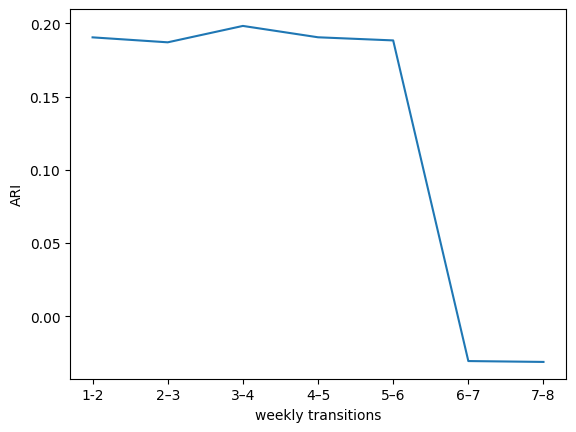

In [66]:
plt.plot(list(ARI_scores.values()))
plt.ylabel('ARI')
plt.xlabel('weekly transitions')
labels = ['1-2', '2–3', '3–4', '4–5', '5–6', '6–7', '7–8']
plt.xticks(ticks=range(len(labels)), labels=labels)